 # 03 — RKHS and Robust Functional Classification on Raw spectra



 This notebook evaluates two functional classification families described in the review:



 1. **RKHS-based classification**

    - Kernel Fisher Discriminant



 2. **Robust functional classification**

    - Fraiman–Muniz depth classifier

    - h-mode depth classifier

    - Random projection depth classifier



 Data:

 - raw sampled spectra `xp_sampled_raw.csv`

 - labels from `og_xp.csv`

 - predefined repeated stratified CV splits from `splits_rskf.json`



 Goal:

 - test whether RKHS and robust depth-based methods improve over earlier functional approaches.



 Outputs:

 - rkhs_robust__rskf_metrics.csv
- rkhs_robust__summary.csv
- rkhs_robust__table.csv
- rkhs_robust__best_by_family.csv
- rkhs_robust__vs_baselines.csv

In [4]:
from __future__ import annotations

import os
import json
import warnings
from datetime import datetime
from pathlib import Path
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import pairwise_kernels

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


 ## 1. Configuration



In [ ]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "og_data"
RAW_FILE_CANDIDATES = [
    DATA_DIR / "og_xp.csv",
]
OUT_DIR = BASE_DIR / "results" / "final_functional"
NOTEBOOK_NAME = "03_rkhs_robust_raw"
SMOKE = False
REPRESENTATION_CHOICE = "raw_xp_sampled"

# RKHS settings
KERNEL_CONFIGS = [
    ("rbf", {"gamma": 0.01}),
    ("rbf", {"gamma": 0.05}),
    ("rbf", {"gamma": 0.10}),
    ("poly", {"degree": 2, "gamma": 0.01, "coef0": 1.0}),
]

KFD_REG = 1e-3

# Robust settings
FM_GRID_SIZE = 30
HMODE_BANDWIDTH_MULTS = [0.5, 1.0, 2.0]
RP_DEPTH_DIRS = 50


 ## 2. Helper functions for file loading

In [6]:
def find_first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None

def find_first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None

def find_representation_file(poly_dir: Path, choice: str) -> Path:
    """
    Try several common filename patterns for one chosen representation.
    """
    patterns = [
        f"{choice}_reconstructed_wide.csv",
        f"{choice}_reconstructed.csv",
        f"{choice}_aligned_reconstructed.csv",
        f"{choice}_spectra.csv",
        f"{choice}_L2.csv",
        f"{choice}.csv",
    ]

    for name in patterns:
        p = poly_dir / name
        if p.exists():
            return p

    # fallback: any csv containing the chosen keyword
    matches = sorted(poly_dir.glob(f"*{choice}*.csv"))
    if matches:
        return matches[0]

    raise FileNotFoundError(
        f"Could not find a reconstructed file for '{choice}' in {poly_dir}."
    )

def infer_feature_columns(df: pd.DataFrame) -> list[str]:
    preferred_prefixes = ("wl_", "flux_", "xp_", "f_")

    pref_cols = [c for c in df.columns if c.startswith(preferred_prefixes)]
    if len(pref_cols) >= 10:
        return pref_cols

    meta_like = {
        "source_id", "y", "label", "target", "ra", "dec", "solution_id",
        "object_id", "objid", "designation", "class"
    }

    num_cols = [
        c for c in df.columns
        if c not in meta_like and pd.api.types.is_numeric_dtype(df[c])
    ]

    if len(num_cols) < 10:
        raise ValueError("Could not infer enough feature columns.")

    return num_cols

def infer_wavelengths(cols: list[str]) -> np.ndarray:
    try:
        return np.array([float(c.split("_", 1)[1]) for c in cols], dtype=np.float64)
    except Exception:
        return np.arange(len(cols), dtype=np.float64)



 ## 3. Load representation and labels

In [7]:
df_rep = pd.read_csv(BASE_DIR / "xp_sampled_spectra.csv")
df_lab = pd.read_csv(BASE_DIR / "og_xp.csv")

df_rep = df_rep.drop(columns=["y"], errors="ignore")

df_m = df_lab[["source_id", "y"]].merge(
    df_rep,
    on="source_id",
    how="inner",
    validate="one_to_one",
)

feature_cols = infer_feature_columns(df_m)
wavelengths = infer_wavelengths(feature_cols)

X_raw = df_m[feature_cols].to_numpy(dtype=np.float64)
y = df_m["y"].to_numpy(dtype=np.int64)

print("Merged shape:", df_m.shape)
print("Feature matrix shape:", X_raw.shape)
print(pd.Series(y).value_counts().sort_index())
X = X_raw.copy()

n, p = X.shape
print("n, p =", n, p)


Merged shape: (2815, 345)
Feature matrix shape: (2815, 343)
0    2257
1     558
Name: count, dtype: int64
n, p = 2815 343


 ## 4. Load predefined repeated stratified splits

In [8]:
with open(BASE_DIR / "splits_rskf.json") as f:
    splits = json.load(f)

def split_sort_key(k: str):
    rep = int(k.split("_")[0].replace("rep", ""))
    fold = int(k.split("_")[1].replace("fold", ""))
    return (rep, fold)

split_names = sorted(splits.keys(), key=split_sort_key)

if SMOKE:
    split_names = [k for k in split_names if k.startswith("rep0_")]
    print(f"SMOKE mode: using {len(split_names)} splits")
else:
    print(f"Full mode: using {len(split_names)} splits")

print(f"Loaded {len(split_names)} splits")

Full mode: using 50 splits
Loaded 50 splits


 ## 5. Diagnostic plot of the chosen representation

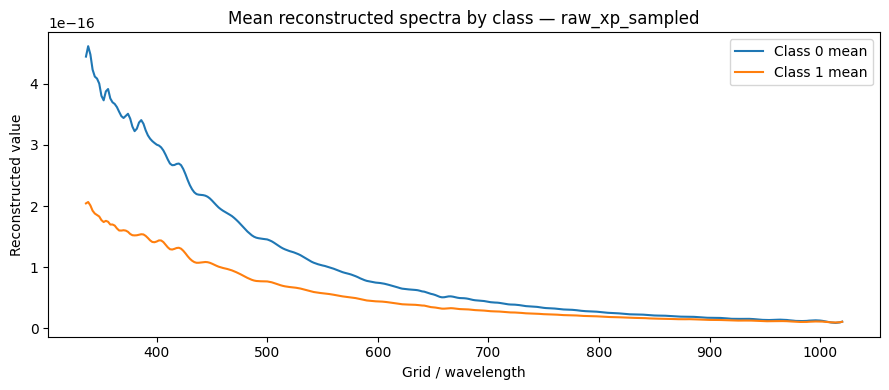

In [9]:
plt.figure(figsize=(9, 4))
plt.plot(wavelengths, X_raw[y == 0].mean(axis=0), label="Class 0 mean")
plt.plot(wavelengths, X_raw[y == 1].mean(axis=0), label="Class 1 mean")
plt.xlabel("Grid / wavelength")
plt.ylabel("Reconstructed value")
plt.title(f"Mean reconstructed spectra by class — {REPRESENTATION_CHOICE}")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


 ## 6. Metric helpers



 PR-AUC and ROC-AUC are computed from continuous scores.

 Threshold-based metrics are computed using a Youden-optimal threshold selected on the training fold.

In [10]:
def normalize_scores_train_ref(scores_te: np.ndarray, scores_tr: np.ndarray) -> np.ndarray:
    lo, hi = float(np.min(scores_tr)), float(np.max(scores_tr))
    if hi == lo:
        return np.full_like(scores_te, 0.5, dtype=np.float64)
    return ((scores_te - lo) / (hi - lo)).astype(np.float64)

def pick_youden_threshold(y_true: np.ndarray, y_prob: np.ndarray, grid_size: int = 200) -> float:
    thresholds = np.linspace(0, 1, grid_size)
    best_j, best_thr = -1.0, 0.5
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(np.int64)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        j = sens + spec - 1.0
        if j > best_j:
            best_j, best_thr = j, float(thr)
    return best_thr

def fold_metrics(
    y_true_te: np.ndarray,
    y_score_te: np.ndarray,
    y_true_tr: np.ndarray,
    y_score_tr: np.ndarray,
) -> dict:
    out = {"pr_auc": average_precision_score(y_true_te, y_score_te)}

    try:
        out["roc_auc"] = float(roc_auc_score(y_true_te, y_score_te))
    except ValueError:
        out["roc_auc"] = np.nan

    prob_tr = normalize_scores_train_ref(y_score_tr, y_score_tr)
    prob_te = normalize_scores_train_ref(y_score_te, y_score_tr)
    thr = pick_youden_threshold(y_true_tr, prob_tr)
    y_pred = (prob_te >= thr).astype(np.int64)

    out["youden_threshold"] = thr
    out["sensitivity"] = recall_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["precision"] = precision_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["specificity"] = recall_score(y_true_te, y_pred, pos_label=0, zero_division=0)
    out["accuracy"] = accuracy_score(y_true_te, y_pred)
    out["f1"] = f1_score(y_true_te, y_pred, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    out["youden_j"] = sens + spec - 1.0

    return out

def fmt_ms(series: pd.Series) -> str:
    m = series.mean()
    s = series.std(ddof=1) if len(series) > 1 else 0.0
    return f"{m:.4f} ± {s:.4f}"


 ## 7. RKHS method: Kernel Fisher Discriminant



 This is a dual / kernel-form Fisher discriminant:

 - compute a kernel matrix on the training curves

 - estimate between-class mean separation in RKHS

 - regularise the within-class scatter operator

 - obtain decision scores for train and test curves

In [11]:
class KernelFisherBinary:
    """
    Binary kernel Fisher discriminant in dual form.

    alpha = (N + lambda I)^(-1) (m1 - m0)

    where:
    - N is the within-class scatter matrix in kernel space
    - m1 - m0 is the difference of class mean embeddings
    """
    def __init__(self, kernel="rbf", kernel_params=None, reg=1e-3):
        self.kernel = kernel
        self.kernel_params = kernel_params if kernel_params is not None else {}
        self.reg = reg

        self.X_train_ = None
        self.alpha_ = None
        self.train_scores_ = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.int64)

        if set(np.unique(y)) != {0, 1}:
            raise ValueError("KernelFisherBinary requires binary labels 0/1.")

        self.X_train_ = X

        K = pairwise_kernels(
            X, X,
            metric=self.kernel,
            filter_params=True,
            **self.kernel_params
        )

        idx0 = np.where(y == 0)[0]
        idx1 = np.where(y == 1)[0]
        n0 = len(idx0)
        n1 = len(idx1)

        one0 = np.zeros((len(y), 1))
        one1 = np.zeros((len(y), 1))
        one0[idx0, 0] = 1.0 / n0
        one1[idx1, 0] = 1.0 / n1

        m0 = K @ one0
        m1 = K @ one1
        m_diff = (m1 - m0).reshape(-1, 1)

        H0 = np.eye(n0) - np.ones((n0, n0)) / n0
        H1 = np.eye(n1) - np.ones((n1, n1)) / n1

        K0 = K[:, idx0]
        K1 = K[:, idx1]

        N0 = K0 @ H0 @ K0.T
        N1 = K1 @ H1 @ K1.T
        N = N0 + N1 + self.reg * np.eye(len(y))

        self.alpha_ = np.linalg.solve(N, m_diff).ravel()
        self.train_scores_ = K @ self.alpha_
        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        Kx = pairwise_kernels(
            np.asarray(X, dtype=np.float64),
            self.X_train_,
            metric=self.kernel,
            filter_params=True,
            **self.kernel_params
        )
        return Kx @ self.alpha_


 ## 8. Robust methods: depth functions



 We implement three robust depth-based scorers:



 1. **Fraiman–Muniz depth**

 2. **h-mode depth**

 3. **Random projection depth**



 Classification rule:

 - compute the depth of each curve with respect to class 0 training curves

 - compute the depth of each curve with respect to class 1 training curves

 - classify by the depth difference:



 \[score(x) = depth_1(x) - depth_0(x)\]

In [12]:
def scores_from_depth_difference(depth0: np.ndarray, depth1: np.ndarray) -> np.ndarray:
    return depth1 - depth0


 ### 8.1 Fraiman–Muniz depth

In [13]:
def fm_depth_scores(X_ref: np.ndarray, X_query: np.ndarray, grid_idx: np.ndarray | None = None) -> np.ndarray:
    """
    Approximate Fraiman–Muniz depth by averaging pointwise depth values over a finite grid.
    """
    _, p_loc = X_ref.shape
    if grid_idx is None:
        grid_idx = np.arange(p_loc)

    D = np.zeros(X_query.shape[0], dtype=np.float64)

    for t in grid_idx:
        ref_t = X_ref[:, t]
        qry_t = X_query[:, t]
        cdf = (ref_t[None, :] <= qry_t[:, None]).mean(axis=1)
        D += 1.0 - np.abs(0.5 - cdf)

    D /= len(grid_idx)
    return D

def run_fm_depth_fold(X_tr: np.ndarray, y_tr: np.ndarray, X_te: np.ndarray, grid_idx: np.ndarray):
    X0 = X_tr[y_tr == 0]
    X1 = X_tr[y_tr == 1]

    d0_tr = fm_depth_scores(X0, X_tr, grid_idx=grid_idx)
    d1_tr = fm_depth_scores(X1, X_tr, grid_idx=grid_idx)
    d0_te = fm_depth_scores(X0, X_te, grid_idx=grid_idx)
    d1_te = fm_depth_scores(X1, X_te, grid_idx=grid_idx)

    score_tr = scores_from_depth_difference(d0_tr, d1_tr)
    score_te = scores_from_depth_difference(d0_te, d1_te)
    return score_tr, score_te


 ### 8.2 h-mode depth

In [14]:
def pairwise_l2_sq(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    A2 = np.sum(A * A, axis=1)[:, None]
    B2 = np.sum(B * B, axis=1)[None, :]
    D2 = A2 + B2 - 2.0 * (A @ B.T)
    return np.maximum(D2, 0.0)

def median_pairwise_distance(X_loc: np.ndarray) -> float:
    D2 = pairwise_l2_sq(X_loc, X_loc)
    tri = np.sqrt(np.maximum(D2[np.triu_indices_from(D2, k=1)], 0.0))
    tri = tri[tri > 0]
    if len(tri) == 0:
        return 1.0
    return float(np.median(tri))

def hmode_depth_scores(X_ref: np.ndarray, X_query: np.ndarray, bandwidth: float) -> np.ndarray:
    """
    h-mode depth using a Gaussian kernel on L2 distances between full curves.
    """
    D2 = pairwise_l2_sq(X_query, X_ref)
    h2 = max(bandwidth ** 2, 1e-12)
    return np.exp(-D2 / (2.0 * h2)).mean(axis=1)

def run_hmode_depth_fold(X_tr: np.ndarray, y_tr: np.ndarray, X_te: np.ndarray, bandwidth_mult: float):
    X0 = X_tr[y_tr == 0]
    X1 = X_tr[y_tr == 1]

    h0 = bandwidth_mult * median_pairwise_distance(X0)
    h1 = bandwidth_mult * median_pairwise_distance(X1)

    d0_tr = hmode_depth_scores(X0, X_tr, bandwidth=h0)
    d1_tr = hmode_depth_scores(X1, X_tr, bandwidth=h1)
    d0_te = hmode_depth_scores(X0, X_te, bandwidth=h0)
    d1_te = hmode_depth_scores(X1, X_te, bandwidth=h1)

    score_tr = scores_from_depth_difference(d0_tr, d1_tr)
    score_te = scores_from_depth_difference(d0_te, d1_te)
    return score_tr, score_te


 ### 8.3 Random projection depth

In [15]:
def random_projection_depth_scores(
    X_ref: np.ndarray,
    X_query: np.ndarray,
    n_dirs: int = 50,
    seed: int = 42,
) -> np.ndarray:
    """
    Average univariate depth over random projection directions.
    """
    rng_local = np.random.default_rng(seed)
    p_loc = X_ref.shape[1]

    dirs = rng_local.normal(size=(n_dirs, p_loc))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-12

    ref_proj = X_ref @ dirs.T
    qry_proj = X_query @ dirs.T

    out = np.zeros(X_query.shape[0], dtype=np.float64)
    for j in range(n_dirs):
        ref_j = ref_proj[:, j]
        qry_j = qry_proj[:, j]
        cdf = (ref_j[None, :] <= qry_j[:, None]).mean(axis=1)
        out += 1.0 - np.abs(0.5 - cdf)

    out /= n_dirs
    return out

def run_rp_depth_fold(X_tr: np.ndarray, y_tr: np.ndarray, X_te: np.ndarray, n_dirs: int = 50):
    X0 = X_tr[y_tr == 0]
    X1 = X_tr[y_tr == 1]

    d0_tr = random_projection_depth_scores(X0, X_tr, n_dirs=n_dirs, seed=RANDOM_STATE)
    d1_tr = random_projection_depth_scores(X1, X_tr, n_dirs=n_dirs, seed=RANDOM_STATE + 1)
    d0_te = random_projection_depth_scores(X0, X_te, n_dirs=n_dirs, seed=RANDOM_STATE)
    d1_te = random_projection_depth_scores(X1, X_te, n_dirs=n_dirs, seed=RANDOM_STATE + 1)

    score_tr = scores_from_depth_difference(d0_tr, d1_tr)
    score_te = scores_from_depth_difference(d0_te, d1_te)
    return score_tr, score_te


 ## 9. Cross-validation loop



 We evaluate:



 - Kernel Fisher for several kernel configurations

 - Fraiman–Muniz depth

 - h-mode depth for several bandwidth multipliers

 - random projection depth

In [16]:
records = []

if FM_GRID_SIZE >= p:
    fm_grid_idx = np.arange(p)
else:
    fm_grid_idx = np.linspace(0, p - 1, FM_GRID_SIZE).round().astype(int)
    fm_grid_idx = np.unique(fm_grid_idx)

print("Starting evaluation...")

for i_split, sname in enumerate(split_names, start=1):
    tr_idx = np.array(splits[sname]["train"], dtype=int)
    te_idx = np.array(splits[sname]["test"], dtype=int)

    X_tr_raw = X[tr_idx]
    X_te_raw = X[te_idx]
    y_tr = y[tr_idx]
    y_te = y[te_idx]

    # -------------------------------------------------
    # Leak-free standardisation: fit only on train fold
    # -------------------------------------------------
    mu_tr = X_tr_raw.mean(axis=0)
    sd_tr = X_tr_raw.std(axis=0, ddof=0)
    sd_tr = np.where(sd_tr < 1e-12, 1.0, sd_tr)

    X_tr = (X_tr_raw - mu_tr) / sd_tr
    X_te = (X_te_raw - mu_tr) / sd_tr

    print(f"[{i_split}/{len(split_names)}] {sname}")

    # --------------------
    # RKHS: Kernel Fisher
    # --------------------
    for kernel_name, kernel_params in KERNEL_CONFIGS:
        clf = KernelFisherBinary(
            kernel=kernel_name,
            kernel_params=kernel_params,
            reg=KFD_REG,
        )
        clf.fit(X_tr, y_tr)

        score_tr = clf.train_scores_
        score_te = clf.decision_function(X_te)

        met = fold_metrics(y_te, score_te, y_tr, score_tr)

        records.append({
            "split": sname,
            "family": "RKHS",
            "method": "Kernel Fisher",
            "tuning": f"{kernel_name}_{kernel_params}",
            **met,
        })

    # ----------------------------
    # Robust: Fraiman–Muniz depth
    # ----------------------------
    score_tr, score_te = run_fm_depth_fold(
        X_tr, y_tr, X_te, grid_idx=fm_grid_idx
    )
    met = fold_metrics(y_te, score_te, y_tr, score_tr)

    records.append({
        "split": sname,
        "family": "Robust depth",
        "method": "Fraiman-Muniz depth",
        "tuning": f"grid={len(fm_grid_idx)}",
        **met,
    })

    # --------------------
    # Robust: h-mode depth
    # --------------------
    for bw_mult in HMODE_BANDWIDTH_MULTS:
        score_tr, score_te = run_hmode_depth_fold(
            X_tr, y_tr, X_te, bandwidth_mult=bw_mult
        )
        met = fold_metrics(y_te, score_te, y_tr, score_tr)

        records.append({
            "split": sname,
            "family": "Robust depth",
            "method": "h-mode depth",
            "tuning": f"bw_mult={bw_mult}",
            **met,
        })

    # -------------------------------
    # Robust: random projection depth
    # -------------------------------
    score_tr, score_te = run_rp_depth_fold(
        X_tr, y_tr, X_te, n_dirs=RP_DEPTH_DIRS
    )
    met = fold_metrics(y_te, score_te, y_tr, score_tr)

    records.append({
        "split": sname,
        "family": "Robust depth",
        "method": "Random projection depth",
        "tuning": f"n_dirs={RP_DEPTH_DIRS}",
        **met,
    })

df_run = pd.DataFrame(records)
print(df_run.head())

Starting evaluation...
[1/50] rep0_fold0


[2/50] rep0_fold1
[3/50] rep0_fold2
[4/50] rep0_fold3
[5/50] rep0_fold4
[6/50] rep1_fold0
[7/50] rep1_fold1
[8/50] rep1_fold2
[9/50] rep1_fold3
[10/50] rep1_fold4
[11/50] rep2_fold0
[12/50] rep2_fold1
[13/50] rep2_fold2
[14/50] rep2_fold3
[15/50] rep2_fold4
[16/50] rep3_fold0
[17/50] rep3_fold1
[18/50] rep3_fold2
[19/50] rep3_fold3
[20/50] rep3_fold4
[21/50] rep4_fold0
[22/50] rep4_fold1
[23/50] rep4_fold2
[24/50] rep4_fold3
[25/50] rep4_fold4
[26/50] rep5_fold0
[27/50] rep5_fold1
[28/50] rep5_fold2
[29/50] rep5_fold3
[30/50] rep5_fold4
[31/50] rep6_fold0
[32/50] rep6_fold1
[33/50] rep6_fold2
[34/50] rep6_fold3
[35/50] rep6_fold4
[36/50] rep7_fold0
[37/50] rep7_fold1
[38/50] rep7_fold2
[39/50] rep7_fold3
[40/50] rep7_fold4
[41/50] rep8_fold0
[42/50] rep8_fold1
[43/50] rep8_fold2
[44/50] rep8_fold3
[45/50] rep8_fold4
[46/50] rep9_fold0
[47/50] rep9_fold1
[48/50] rep9_fold2
[49/50] rep9_fold3
[50/50] rep9_fold4
        split        family               method  \
0  rep0_fold0          RK

 ## 10. Save per-fold metrics

In [17]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

metrics_path = OUT_DIR / (
    f"{NOTEBOOK_NAME}_{REPRESENTATION_CHOICE}_rskf_metrics_{timestamp}.csv"
)
df_run.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)


Saved: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\03_rkhs_robust_raw_raw_xp_sampled_rskf_metrics_20260409_2056.csv


 ## 11. Summary table

In [18]:
METRIC_COLS = [
    "pr_auc",
    "roc_auc",
    "sensitivity",
    "precision",
    "specificity",
    "accuracy",
    "f1",
    "youden_j",
    "youden_threshold",
]

agg_dict = {}
for m in METRIC_COLS:
    agg_dict[f"{m}_mean"] = pd.NamedAgg(column=m, aggfunc="mean")
    agg_dict[f"{m}_std"] = pd.NamedAgg(column=m, aggfunc="std")

df_agg = (
    df_run.groupby(["family", "method", "tuning"])
    .agg(**agg_dict)
    .reset_index()
    .sort_values(["pr_auc_mean", "f1_mean", "roc_auc_mean"], ascending=False)
    .reset_index(drop=True)
)

summary_path = OUT_DIR / (
    f"{NOTEBOOK_NAME}_{REPRESENTATION_CHOICE}_summary_{timestamp}.csv"
)
df_agg.to_csv(summary_path, index=False)
print("Saved:", summary_path)


Saved: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\03_rkhs_robust_raw_raw_xp_sampled_summary_20260409_2056.csv


In [19]:
def mean_std_text(df_part: pd.DataFrame, key: str) -> list[str]:
    return [
        f"{m:.4f} ± {0.0 if pd.isna(s) else s:.4f}"
        for m, s in zip(df_part[f"{key}_mean"], df_part[f"{key}_std"])
    ]

df_table = pd.DataFrame({
    "Family": df_agg["family"],
    "Method": df_agg["method"],
    "Tuning": df_agg["tuning"],
    "PR-AUC mean ± std": mean_std_text(df_agg, "pr_auc"),
    "ROC-AUC mean ± std": mean_std_text(df_agg, "roc_auc"),
    "Sensitivity mean ± std": mean_std_text(df_agg, "sensitivity"),
    "Precision mean ± std": mean_std_text(df_agg, "precision"),
    "F1 mean ± std": mean_std_text(df_agg, "f1"),
    "Youden J mean ± std": mean_std_text(df_agg, "youden_j"),
})

print("\n=== TOP METHODS ===")
print(df_table.head(20).to_string(index=False))

table_path = OUT_DIR / (
    f"{NOTEBOOK_NAME}_{REPRESENTATION_CHOICE}_table_{timestamp}.csv"
)
df_table.to_csv(table_path, index=False)
print("Saved:", table_path)



=== TOP METHODS ===
      Family                  Method                                          Tuning PR-AUC mean ± std ROC-AUC mean ± std Sensitivity mean ± std Precision mean ± std   F1 mean ± std Youden J mean ± std
Robust depth Random projection depth                                       n_dirs=50   0.2895 ± 0.0286    0.6023 ± 0.0254        0.5710 ± 0.0411      0.2603 ± 0.0165 0.3573 ± 0.0209     0.1691 ± 0.0414
Robust depth     Fraiman-Muniz depth                                         grid=30   0.2713 ± 0.0315    0.5592 ± 0.0280        0.4977 ± 0.1401      0.2503 ± 0.0622 0.3109 ± 0.0439     0.0951 ± 0.0512
Robust depth            h-mode depth                                     bw_mult=0.5   0.2017 ± 0.0045    0.5075 ± 0.0126        0.9099 ± 0.2717      0.1850 ± 0.0552 0.3074 ± 0.0917     0.0149 ± 0.0237
Robust depth            h-mode depth                                     bw_mult=1.0   0.2017 ± 0.0045    0.5075 ± 0.0126        0.9099 ± 0.2717      0.1850 ± 0.0552 0.307

 ## 12. Best method within each family

In [20]:
best_by_family = (
    df_agg.sort_values(["pr_auc_mean", "f1_mean"], ascending=False)
    .groupby("family", as_index=False)
    .first()
)

best_family_table = pd.DataFrame({
    "Family": best_by_family["family"],
    "Method": best_by_family["method"],
    "Tuning": best_by_family["tuning"],
    "PR-AUC mean ± std": [
        f"{m:.4f} ± {0.0 if pd.isna(s) else s:.4f}"
        for m, s in zip(best_by_family["pr_auc_mean"], best_by_family["pr_auc_std"])
    ],
    "ROC-AUC mean ± std": [
        f"{m:.4f} ± {0.0 if pd.isna(s) else s:.4f}"
        for m, s in zip(best_by_family["roc_auc_mean"], best_by_family["roc_auc_std"])
    ],
    "F1 mean ± std": [
        f"{m:.4f} ± {0.0 if pd.isna(s) else s:.4f}"
        for m, s in zip(best_by_family["f1_mean"], best_by_family["f1_std"])
    ],
})

print("\n=== BEST BY FAMILY ===")
print(best_family_table.to_string(index=False))

best_family_path = OUT_DIR / (
    f"{NOTEBOOK_NAME}_{REPRESENTATION_CHOICE}_best_by_family_{timestamp}.csv"
)
best_family_table.to_csv(best_family_path, index=False)
print("Saved:", best_family_path)



=== BEST BY FAMILY ===
      Family                  Method                                          Tuning PR-AUC mean ± std ROC-AUC mean ± std   F1 mean ± std
        RKHS           Kernel Fisher poly_{'degree': 2, 'gamma': 0.01, 'coef0': 1.0}   0.1982 ± 0.0009    0.5000 ± 0.0000 0.3309 ± 0.0012
Robust depth Random projection depth                                       n_dirs=50   0.2895 ± 0.0286    0.6023 ± 0.0254 0.3573 ± 0.0209
Saved: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\03_rkhs_robust_raw_raw_xp_sampled_best_by_family_20260409_2056.csv


 ## 13. Best current method

In [21]:
best_row = df_agg.iloc[0]

print("\n=== BEST CURRENT METHOD ===")
print(f"Representation: {REPRESENTATION_CHOICE}")
print(f"Family:         {best_row['family']}")
print(f"Method:         {best_row['method']}")
print(f"Tuning:         {best_row['tuning']}")
print(f"PR-AUC:         {best_row['pr_auc_mean']:.4f} ± {best_row['pr_auc_std']:.4f}")
print(f"ROC-AUC:        {best_row['roc_auc_mean']:.4f} ± {best_row['roc_auc_std']:.4f}")
print(f"F1:             {best_row['f1_mean']:.4f} ± {best_row['f1_std']:.4f}")



=== BEST CURRENT METHOD ===
Representation: raw_xp_sampled
Family:         Robust depth
Method:         Random projection depth
Tuning:         n_dirs=50
PR-AUC:         0.2895 ± 0.0286
ROC-AUC:        0.6023 ± 0.0254
F1:             0.3573 ± 0.0209


 ## 14. Saved files

In [23]:
print("Saved files:")
print("-", metrics_path)
print("-", summary_path)
print("-", table_path)
print("-", best_family_path)

Saved files:
- c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\03_rkhs_robust_raw_raw_xp_sampled_rskf_metrics_20260409_2056.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\03_rkhs_robust_raw_raw_xp_sampled_summary_20260409_2056.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\03_rkhs_robust_raw_raw_xp_sampled_table_20260409_2056.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\03_rkhs_robust_raw_raw_xp_sampled_best_by_family_20260409_2056.csv
